# RACE Dataset — Exploratory Data Analysis

**Project:** AL2002 Lab Project — Q&A Generator and Answer Verifier  
**Dataset:** RACE (ankitdhiman7/race-dataset on Kaggle)  
**Goal:** Understand the distribution of articles, questions, options, and answers before model design.

---
## Sections
1. Setup & Data Loading
2. Basic Inspection (shape, dtypes, nulls, duplicates)
3. Answer Label Distribution
4. Article Length Distribution
5. Question Length Distribution
6. Option Length Distributions (A / B / C / D)
7. Top-N Most Frequent Words
8. Word Cloud (Articles & Questions)
9. Question-Type Analysis (Wh-words)
10. Summary Statistics Table

## 1. Setup & Data Loading

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

from src.data_loader import load_splits
train_df, val_df, test_df = load_splits()

print(f'Train: {train_df.shape}')
print(f'Val:   {val_df.shape}')
print(f'Test:  {test_df.shape}')

Train: (61496, 8)
Val:   (13178, 8)
Test:  (13178, 8)


## 2. Basic Inspection

In [2]:
print('Columns:', list(train_df.columns))
print('\nDtypes:')
print(train_df.dtypes)
print('\nNulls per column:')
print(train_df.isnull().sum())
print(f'\nDuplicate rows: {train_df.duplicated().sum()}')
print(f'Unique articles (by id): {train_df["id"].nunique()}')
train_df.head(2)

Columns: ['id', 'article', 'question', 'A', 'B', 'C', 'D', 'answer']

Dtypes:
id          object
article     object
question    object
A           object
B           object
C           object
D           object
answer      object
dtype: object

Nulls per column:


id          0
article     0
question    0
A           0
B           0
C           0
D           0
answer      0
dtype: int64



Duplicate rows: 0
Unique articles (by id): 24346


,id,article,question,A,B,C,D,answer
0,high4770.txt,Can we give a hand to those endangered animals...,People are advised to put decals on windows to...,decorate the houses and beautify the environment,protect the windows from birds hitting,attract more birds to make homes nearby,avoid birds hitting the windows by mistake,D
1,middle1469.txt,March 5 is Lei Feng Day. Lei Feng is one of th...,Zhu Lingyue _ on that day.,cleaned the yard,cleaned the teachers's office,cleaned a square,cleaned a hospital.,B


## 3. Answer Label Distribution

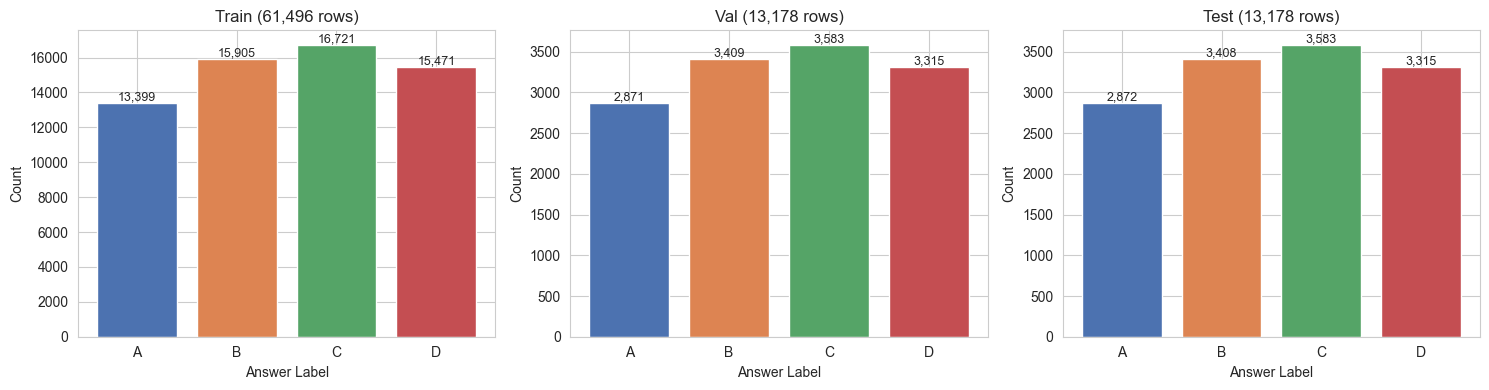


Answer % distribution (Train):
answer
C    27.19
B    25.86
D    25.16
A    21.79


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, df, name in zip(axes, [train_df, val_df, test_df], ['Train', 'Val', 'Test']):
    counts = df['answer'].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=['#4C72B0', '#DD8452', '#55A467', '#C44E52'])
    ax.set_title(f'{name} ({len(df):,} rows)')
    ax.set_xlabel('Answer Label')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print('\nAnswer % distribution (Train):')
print((train_df['answer'].value_counts(normalize=True) * 100).round(2).to_string())

## 4. Article Length Distribution

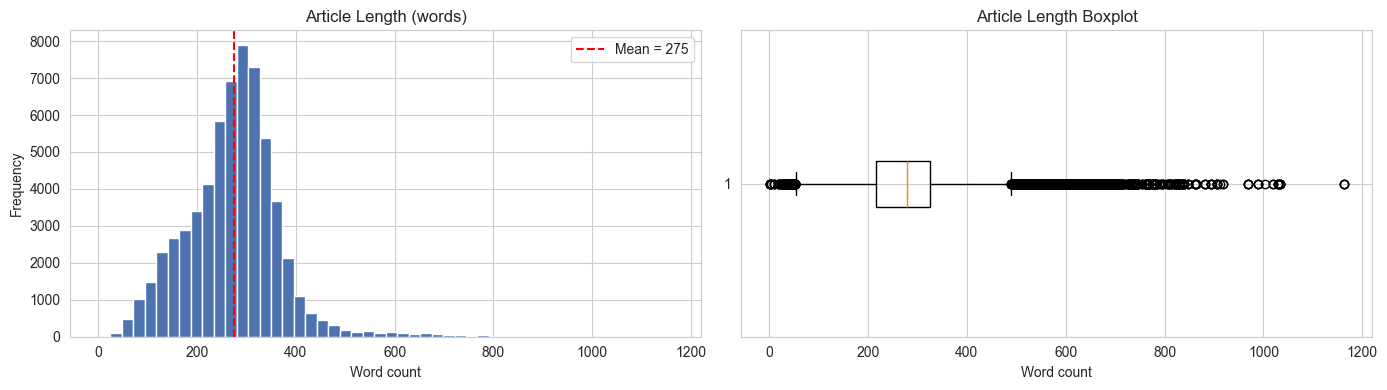

count    61496.0
mean       274.6
std         97.9
min          2.0
25%        217.0
50%        279.0
75%        326.0
max       1162.0


In [4]:
train_df['article_len_words'] = train_df['article'].str.split().str.len()
train_df['article_len_chars'] = train_df['article'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(train_df['article_len_words'], bins=50, color='#4C72B0', edgecolor='white')
axes[0].set_title('Article Length (words)')
axes[0].set_xlabel('Word count')
axes[0].set_ylabel('Frequency')
axes[0].axvline(train_df['article_len_words'].mean(), color='red', ls='--', label=f"Mean = {train_df['article_len_words'].mean():.0f}")
axes[0].legend()

axes[1].boxplot(train_df['article_len_words'], vert=False)
axes[1].set_title('Article Length Boxplot')
axes[1].set_xlabel('Word count')
plt.tight_layout()
plt.show()

print(train_df['article_len_words'].describe().round(1).to_string())

## 5. Question Length Distribution

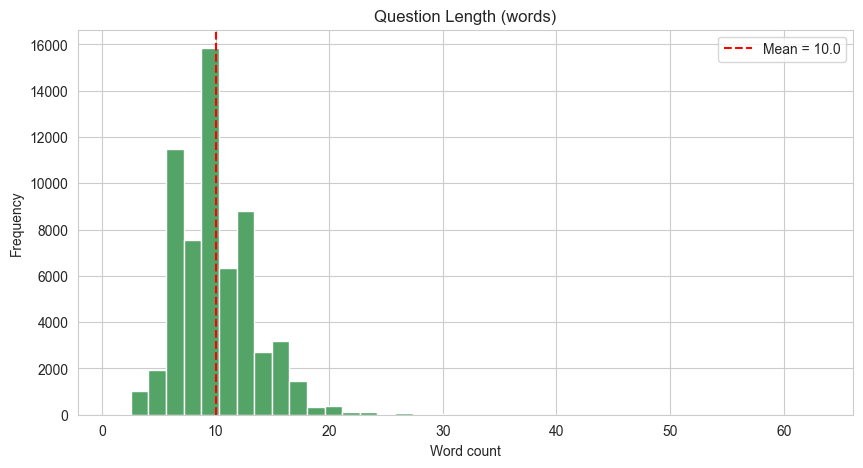

count    61496.0
mean        10.0
std          3.4
min          1.0
25%          8.0
50%         10.0
75%         12.0
max         63.0


In [5]:
train_df['q_len_words'] = train_df['question'].str.split().str.len()

plt.hist(train_df['q_len_words'], bins=40, color='#55A467', edgecolor='white')
plt.title('Question Length (words)')
plt.xlabel('Word count')
plt.ylabel('Frequency')
plt.axvline(train_df['q_len_words'].mean(), color='red', ls='--', label=f"Mean = {train_df['q_len_words'].mean():.1f}")
plt.legend()
plt.show()

print(train_df['q_len_words'].describe().round(1).to_string())

## 6. Option Length Distributions

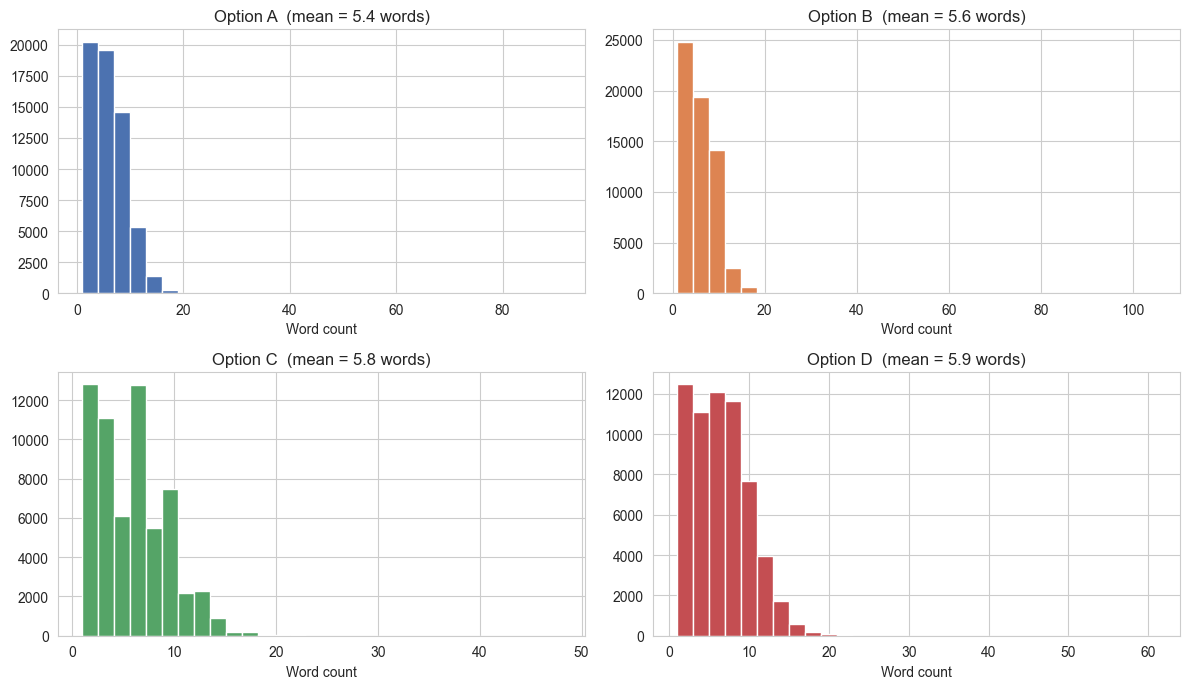

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, opt, color in zip(axes.flat, ['A', 'B', 'C', 'D'], ['#4C72B0', '#DD8452', '#55A467', '#C44E52']):
    lens = train_df[opt].astype(str).str.split().str.len()
    ax.hist(lens, bins=30, color=color, edgecolor='white')
    ax.set_title(f'Option {opt}  (mean = {lens.mean():.1f} words)')
    ax.set_xlabel('Word count')
plt.tight_layout()
plt.show()

## 7. Top-N Most Frequent Words (Articles)

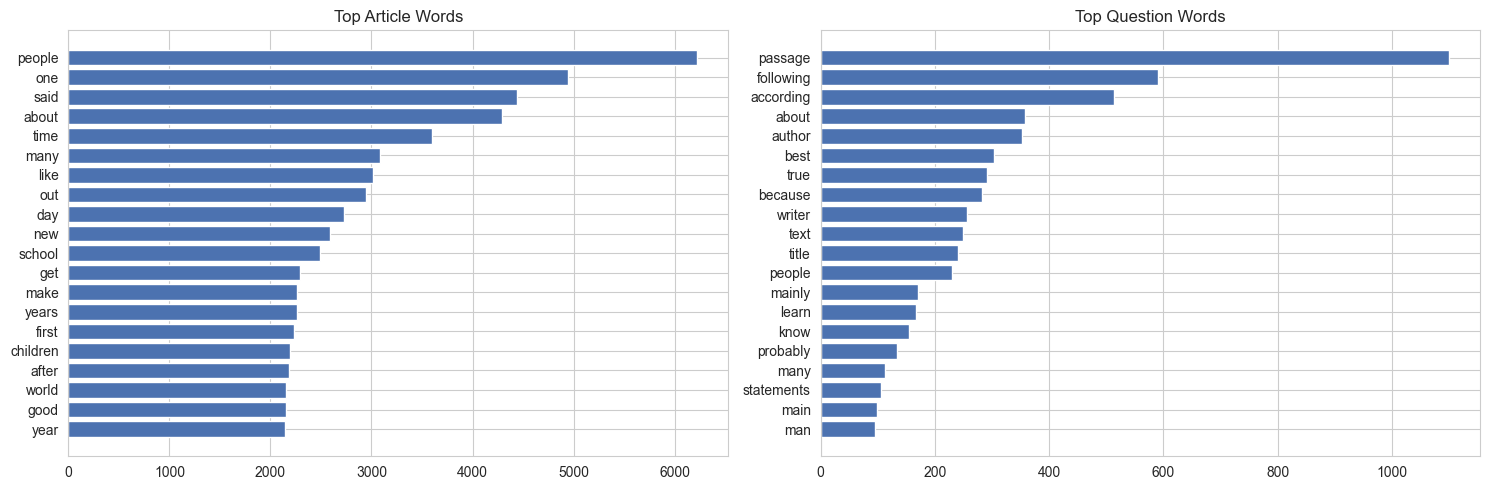

In [7]:
STOPWORDS = set("""a an the is are was were be been being have has had do does did will would shall should can could may might must of in on at to for with by from as and or but if then so than that this these those i you he she it we they me him her us them my your his its our their what which who whom whose how when where why not no yes also there here just very more most some any all each every other another such only own same too s t don re ll d m o ve y ain aren couldn didn doesn hadn hasn haven isn ma mightn mustn needn shan shouldn wasn weren won wouldn""".split())

def top_words(text_series, n=20):
    counter = Counter()
    for txt in text_series.astype(str).str.lower():
        tokens = re.findall(r"[a-z]+", txt)
        counter.update(t for t in tokens if t not in STOPWORDS and len(t) > 2)
    return counter.most_common(n)

# Sample for speed
sample = train_df.sample(5000, random_state=42)
top_article = top_words(sample['article'], 20)
top_question = top_words(sample['question'], 20)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, data, title in zip(axes, [top_article, top_question], ['Top Article Words', 'Top Question Words']):
    words, counts = zip(*data)
    ax.barh(words[::-1], counts[::-1], color='#4C72B0')
    ax.set_title(title)
plt.tight_layout()
plt.show()

## 8. Word Cloud (Optional — requires `wordcloud` package)

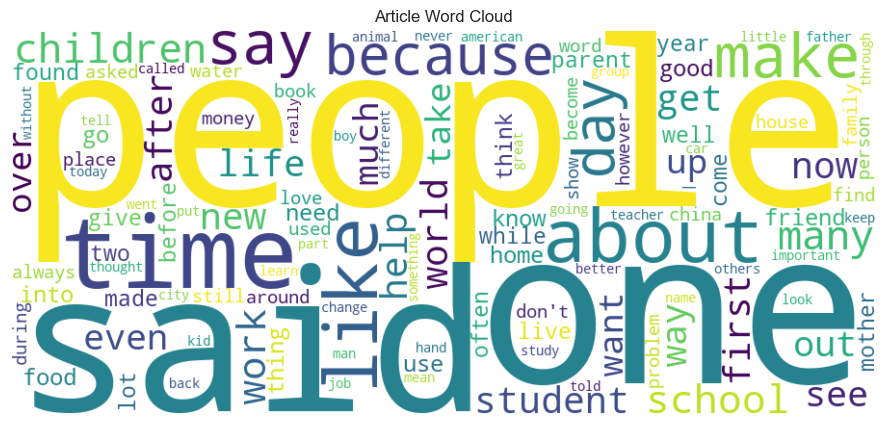

In [8]:
try:
    from wordcloud import WordCloud
    text = ' '.join(sample['article'].astype(str).str.lower())
    wc = WordCloud(width=900, height=400, background_color='white', stopwords=STOPWORDS, max_words=120).generate(text)
    plt.figure(figsize=(12, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title('Article Word Cloud')
    plt.show()
except ImportError:
    print('Install wordcloud: pip install wordcloud')

## 9. Question Type Analysis (Wh-words)

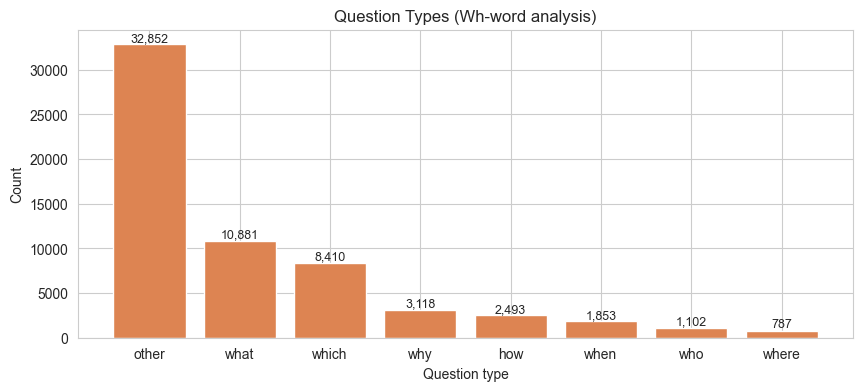

q_type
other    32852
what     10881
which     8410
why       3118
how       2493
when      1853
who       1102
where      787


In [9]:
WH_WORDS = ['what', 'who', 'where', 'when', 'why', 'how', 'which']

def classify_question(q):
    q_lower = str(q).lower()
    for wh in WH_WORDS:
        if wh in q_lower.split()[:5]:
            return wh
    return 'other'

train_df['q_type'] = train_df['question'].apply(classify_question)
qtype_counts = train_df['q_type'].value_counts()

plt.figure(figsize=(10, 4))
plt.bar(qtype_counts.index, qtype_counts.values, color='#DD8452')
plt.title('Question Types (Wh-word analysis)')
plt.xlabel('Question type')
plt.ylabel('Count')
for i, v in enumerate(qtype_counts.values):
    plt.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)
plt.show()

print(qtype_counts.to_string())

## 10. Summary Statistics Table

In [10]:
summary = pd.DataFrame({
    'Metric': [
        'Total questions (Train+Val+Test)',
        'Train rows',
        'Val rows',
        'Test rows',
        'Unique articles (Train)',
        'Avg article length (words)',
        'Avg question length (words)',
        'Median article length (words)',
        'Most common answer label',
        'Most common question type',
    ],
    'Value': [
        f'{len(train_df) + len(val_df) + len(test_df):,}',
        f'{len(train_df):,}',
        f'{len(val_df):,}',
        f'{len(test_df):,}',
        f"{train_df['id'].nunique():,}",
        f"{train_df['article_len_words'].mean():.1f}",
        f"{train_df['q_len_words'].mean():.1f}",
        f"{train_df['article_len_words'].median():.0f}",
        train_df['answer'].mode().iloc[0],
        train_df['q_type'].mode().iloc[0],
    ],
})
summary

,Metric,Value
0,Total questions (Train+Val+Test),"87,852"
1,Train rows,"61,496"
2,Val rows,"13,178"
3,Test rows,"13,178"
4,Unique articles (Train),"24,346"
5,Avg article length (words),274.6
6,Avg question length (words),10.0
7,Median article length (words),279
8,Most common answer label,C
9,Most common question type,other


---
## Key Observations

1. **Class imbalance**: Answer labels are not perfectly balanced. Label `C` is most common (~27%), label `A` is least common (~22%). We should use stratified splits and report **Macro-F1** alongside Accuracy.
2. **Article lengths** are right-skewed — most are 200–400 words, but a long tail extends past 1000.
3. **Questions** are short (mean ~10 words) and often start with Wh-words — this validates a template-based generation approach.
4. **Vocabulary is dominated** by common content words (`said`, `time`, `people`, `school`) — One-Hot Encoding with `max_features=10000–20000` should capture most signal.
5. **No major data quality issues** after dropping the 14 rows with null options.

These findings inform our preprocessing choices in the next phase.